In [1]:
import re
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP
from hdbscan import HDBSCAN

try:
    import torch
except Exception:
    torch = None


class IdentityDimensionalityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for p in [start.resolve()] + list(start.resolve().parents):
        if (p / "csvs").exists() and (p / "markdown").exists():
            return p

    return start.resolve()


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.text_mining_utils as tmu


CSVS_CHUNKED = PROJECT_ROOT / "csvs" / "chunked"
CHUNKS_ALL = CSVS_CHUNKED / "chunks_all.csv"
PIPELINE_DIR = PROJECT_ROOT / "progress" / "topic_modelling" / "bertopic" / "policy"
OUT_DIR = PIPELINE_DIR / "output"

OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_DIR = PIPELINE_DIR / "img"
GLOBAL_IMG_DIR = IMG_DIR / "global"
COUNTRY_IMG_DIR = IMG_DIR / "per_country"

IMG_DIR.mkdir(parents=True, exist_ok=True)
GLOBAL_IMG_DIR.mkdir(parents=True, exist_ok=True)
COUNTRY_IMG_DIR.mkdir(parents=True, exist_ok=True)


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 160)

NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
nltk.data.path.append(str(NLTK_DATA_DIR))

nltk_packages = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for package in nltk_packages:
    try:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
    except Exception as e:
        print(f"Warning: NLTK package not available: {package} ({e})")

print("Project root:", PROJECT_ROOT)
print("Input chunks file:", CHUNKS_ALL)
print("Pipeline folder:", PIPELINE_DIR)
print("Output folder:", OUT_DIR)
print("Image folder:", IMG_DIR)
print("Utility module:", None if tmu is None else tmu.__name__)

Project root: /home/nsirim/Github/mscdsa/msc
Input chunks file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Pipeline folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy
Output folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/output
Image folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img
Utility module: scripts.text_mining_utils


In [2]:
# ==========================================
# Step 1: Load policy chunks
# This keeps only policy rows and builds the text used for topic modelling.
# ==========================================

CORPUS_FILTER = "policy"

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "country",
    "heading_context",
    "chunk_text",
}


def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalise_heading_text(heading):
    heading = safe_text(heading)
    heading = re.sub(r"\s+", " ", heading)
    heading = re.sub(r"^\d+(\.\d+)*\s+", "", heading)
    return heading.strip()


def build_original_heading_context_chunk_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if heading and chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    return f"{heading} {chunk_text}".strip()


def build_bertopic_source_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if not heading:
        return chunk_text

    if chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    # Short headings are useful context; long headings may add noise.
    if len(heading.split()) <= 12:
        return f"{heading}. {chunk_text}"

    return chunk_text


def remove_document_artifact_chunks(dataframe):
    artifact_heading_pattern = re.compile(
        r"^(contents|table of contents|acknowledgements?|acknowledgments?|"
        r"acronyms?|abbreviations?|illustrations?|bibliography|references)$",
        re.IGNORECASE,
    )

    dataframe = dataframe.copy()

    heading_is_artifact = (
        dataframe["heading_context"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.match(artifact_heading_pattern)
    )

    text_is_too_short = (
        dataframe["chunk_text"]
        .fillna("")
        .astype(str)
        .str.split()
        .apply(len)
        < 20
    )

    return dataframe[~(heading_is_artifact & text_is_too_short)].copy()


# Use the project path first. If the notebook is run from a copied location,
# fall back to the nearest chunks_all*.csv file.
input_path = CHUNKS_ALL

if not input_path.exists():
    candidates = sorted(PROJECT_ROOT.rglob("chunks_all*.csv"))
    if len(candidates) == 0:
        raise FileNotFoundError(f"Could not find {CHUNKS_ALL} or any chunks_all*.csv file.")
    input_path = candidates[0]
    print("Using fallback chunks file:", input_path)

all_chunks_df = pd.read_csv(input_path)

missing_columns = required_columns.difference(all_chunks_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df = all_chunks_df[all_chunks_df["corpus"].eq(CORPUS_FILTER)].copy()

df["country"] = (
    df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

df["heading_context"] = df["heading_context"].fillna("").astype(str)
df["chunk_text"] = df["chunk_text"].fillna("").astype(str)

df = remove_document_artifact_chunks(df)

df["heading_context_chunk_text"] = df.apply(
    build_original_heading_context_chunk_text,
    axis=1,
)

df["bertopic_source_text"] = df.apply(
    build_bertopic_source_text,
    axis=1,
)

df["raw_word_count"] = df["bertopic_source_text"].apply(lambda text: len(str(text).split()))

df = df[df["bertopic_source_text"].str.strip().ne("")].copy()
df = df.reset_index(drop=True)

print("Policy chunks loaded:", len(df))
print("Policy documents:", df["doc_id"].nunique())
print("\nRows by country:")
print(df["country"].value_counts(dropna=False).to_frame("chunks"))


Policy chunks loaded: 2052
Policy documents: 56

Rows by country:
           chunks
country          
usa           578
ireland       457
australia     436
france        332
unknown       249


In [3]:
# ==========================================
# Step 2: Corpus diagnostics
# This checks whether countries are balanced before modelling.
# ==========================================

diagnostics_df = (
    df.groupby("country")
    .agg(
        documents=("doc_id", "nunique"),
        chunks=("doc_id", "size"),
        mean_words=("raw_word_count", "mean"),
        median_words=("raw_word_count", "median"),
        min_words=("raw_word_count", "min"),
        max_words=("raw_word_count", "max"),
    )
    .reset_index()
    .sort_values("country")
)

print(diagnostics_df)

print("Note: global discovery may be influenced by countries with more chunks.")
print("Per-country discovery is therefore added after the global model.")


     country  documents  chunks  mean_words  median_words  min_words  max_words
0  australia         17     436  239.268349         229.5         41        660
1     france          7     332  259.750000         276.5          8        705
2    ireland         15     457  261.840263         297.0          7        637
3    unknown          2     249  277.506024         327.0         80        449
4        usa         15     578  238.067474         221.0          8       1501
Note: global discovery may be influenced by countries with more chunks.
Per-country discovery is therefore added after the global model.


In [4]:
# ==========================================
# Stopwords
# ==========================================

stop_words = set(SPACY_STOP_WORDS)
stop_words.update(set(stopwords.words("english")))

try:
    stop_words.update(set(stopwords.words("french")))
except Exception:
    print("Warning: French stopwords not found.")

document_artifact_stopwords = [
    "pdf", "qxp", "page", "copyright", "reserved",
    "www", "http", "https", "com", "org",
    "figure", "table", "annex", "appendix", "footnote", "endnote",
    "isbn", "bibliography", "citation", "reference", "metadata", "docx",
    "executive summary", "draft", "matrix", "blueprint", "snapshot",
    "chart", "brochure", "fig"
]

legal_structure_stopwords = [
    "section", "chapter", "part", "title", "article", "clause",
    "paragraph", "subparagraph", "schedule", "exhibit", "supplement",
    "addendum", "preamble", "recital", "report",
    "chapitre", "partie", "titre", "paragraphe", "alinea",
    "annexe", "appendice", "expos", "des", "motifs",
    "disposition"
]

legal_boilerplate_stopwords = [
    "coppa", "ferpa", "enact", "bit",
    "herein", "therein", "thereof", "whereof", "hereby",
    "whereby", "hereinafter", "thereafter", "aforementioned",
    "foregoing", "henceforth", "whereto", "whereupon",
    "notwithstanding", "pursuant", "thereto", "thereunder", "hereto",
    "susmentionn", "prcit", "nonobstant", "par drogation",
    "en", "consquence", "eu", "gard", "aux fins",
    "selon", "conformment", "outre", "ladite", "ledit", "dune"
]

policy_action_stopwords = [
    "shall", "must", "may", "might", "could", "would", "should", "will",
    "require", "requires", "required",
    "ensure", "ensures",
    "seek", "seeks", "seeking",
    "establish", "establishes",
    "promote", "promotes", "promoting",
    "maintain", "respect",
    "doit", "devrait", "pourrait", "vouloir",
    "exiger", "requis", "assurer", "garantir",
    "rechercher", "tablir", "promouvoir",
    "maintenir", "respecter"
]

policy_connector_stopwords = [
    "various", "several", "multiple", "certain", "relevant", "appropriate",
    "regarding", "concerning", "involving", "accordance",
    "relate", "relates", "relating",
    "furthermore", "moreover", "therefore", "thus", "hence",
    "however", "although", "including", "etc", "etcetera",
    "concernant", "divers", "plusieurs", "particulier",
    "certain", "aussi", "de plus", "en outre",
    "par consquent", "donc", "ainsi", "cependant",
    "bien que", "notamment", "entre autres", "comme",
    "toute", "tous", "cette", "plus", "leurs"
]

geo_institutional_stopwords = [
    "ireland", "irish", "france", "french", "usa", "america",
    "australia", "australian",
    "country", "nation", "national", "state",
    "government", "federal", "ministry", "department",
    "gouvernement", "ministre", "dtat", "republic",
    "pittsburg", "antioch", "medina", "winterset",
    "sara", "washington", "california", "massachusetts",
    "oregon", "sweden", "unified", "district",
    "commonwealth", "nsw"
]

tech_ai_stopwords = [
    "artificial", "intelligence",
    "ai", "ia", "lia", "dia",
    "genai", "generative",
    "model", "models", "llm",
    "algorithm", "algorithms",
    "machine", "learning",
    "data", "dataset", "datasets",
    "digital", "numrique",
    "computer", "software", "hardware",
    "technology", "technological",
    "platform", "online", "internet", "web", "electronic",
    "tool", "system", "device", "application", "app", "service",
    "broadband", "connectivity", "vendor", "player", "enterprise",
    "artificielle", "gen", "generatif",
    "modle", "modles",
    "apprentissage", "donn",
    "ordinateur", "logiciel", "matriel",
    "technologie", "plateforme", "ligne",
    "ectronique", "outil", "systme", "dispositif",
    "générative", "intelligent",
    "edge", "gpt", "openai", "microsoft", "google",
    "amazon", "meta", "ibm", "nvidia", "intel",
    "gemini", "deepseek", "anthropic", "claude",
    "embedding", "transformer", "natural language",
    "climate change", "ieee", "architecture",
    "chatgtp", "copilot", "kwyk", "technologies",
    "new", "work", "law", "system", "systems", "right",
    "services", "based", "case", "support", "human",
    "generated", "related"
]

education_stopwords = [
    "school", "education", "educational",
    "pupil", "classroom", "learning",
    "teacher", "teachers", "schools",
    "student", "students",
    "post", "primary", "technical",
    "cole", "educatif", "enseignant", "enseignats", "enseignants",
    "professeur", "programme",
    "apprentissage", "enseignement", "formation",
    "établissement", "éducation", "école",
    "élève", "élèves",
    "covid", "showcase", "deliverable"
]

org_name_stopwords = [
    "adam", "mary", "jensen", "abraham", "lincoln",
    "knight", "kim", "guez",
    "oecd", "cbs", "webwise", "cosn", "dlf",
    "scoilnet", "deap", "dne", "men",
    "parliament", "commissioner", "public sector",
    "cipa", "protection act", "oide", "tie", "cpd"
]

generic_noise_stopwords = [
    "feel", "like", "everybody", "actually",
    "kid", "employee", "min", "box", "loop",
    "black", "asset", "typical", "era",
    "acquire", "behavioral", "behavioural",
    "revolution", "emission", "talent",
    "billion", "count", "witness", "operator",
    "interim", "resourced", "resourcing",
    "round", "support work", "dashboard",
    "ela", "estonia", "pisa", "perspectives",
    "final", "total", "describe", "visit",
    "original", "sample", "low",
    "answer", "ask", "efficacy",
    "deepen", "enhance",
    "author", "researcher", "mission", "personnel",
    "palo", "alto", "card",
    "use", "lot", "enable", "constituent",
    "session", "policy", "document",
    "member", "organisation", "goal",
    "long term", "desirable", "young",
    "ite", "aied", "australasian",
    "perplexed", "guidetoaiinschools", "nenufsd",
    "dent", "fee", "want", "prof", "stu"
]

date_time_stopwords = [
    "july", "april", "august"
]

policy_corpus_checked_stopwords = [
    "create", "level", "plan", "text", "lesson", "area",
    "assist", "example", "resource", "replace", "available",
    "important", "engage", "provide", "include", "develop",
    "development", "support", "need", "make", "work",
    "way", "role", "view", "approach", "activity",
    "consider", "consideration", "identify", "understand",
    "understanding", "information", "implementation", "implement",
    "process", "practice", "practices", "challenge", "challenges",
    "opportunity", "opportunities", "benefit", "benefits",
    "impact", "impacts", "discussion", "debate", "change",
    "future", "key", "range", "effective", "effectively",
    "access", "issue", "issues", "specific", "general",
    "different", "possible", "stakeholder", "stakeholders",
    "initiative", "initiatives", "committee", "commission",
    "advisory", "program", "civil", "carry", "finding", "find"
]

policy_artifact_checked_stopwords = [
    "author", "authors", "printed", "strasbourg", "cedex",
    "shutterstock", "publishing", "cover", "photo",
    "directorate", "communications"
]

post_cleaning_generic_stopwords = [
    "être", "avoir", "faire", "peut",
    "tout", "tous", "toute", "toutes",
    "autre", "autres",
    "encore", "déjà", "non", "sans",
    "dont", "cela", "même", "mme",
    "très", "moins", "plus", "souvent",
    "cas", "type", "manière", "fonction", "partir",
    "exemple", "question", "réponse", "résultat",
    "objectif", "contenu", "texte", "image"
]

fragment_stopwords = [
    "ing", "tion", "ment", "ness", "ly",
    "able", "ive", "ent", "ant",
    "ence", "ance",
    "ali", "gue", "rod", "rodr",
    "educa", "evi", "al", "ons", "onal", "effec", 
    "con", "consulta", "prac"
]


policy_model_artifact_stopwords = [
    "nan", "none", "null",
    "percentage", "percentages",
    "score", "scores",
    "mean", "average",
    "likert",
    "issn",
    "der", "die", "una", "los",
]

policy_final_artifact_stopwords = [
    "vely", "iden", "connec", "informa",
    "cial", "ques", "protec", "crea", "cod",

    "vsv", "ahisa", "tag",
    "respondent", "comment", "select",

    "amp",
    "implementa", "tifi", "nue", "opportuni", "innova",
    "vely", "iden", "connec", "informa",
    "cial", "ques", "protec", "crea", "cod",

    "ini", "vity", "poten", "considera", "suppor",
]

custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    date_time_stopwords,
    policy_corpus_checked_stopwords,
    policy_artifact_checked_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
    policy_model_artifact_stopwords,
    policy_final_artifact_stopwords
]

custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)

stop_words.update(custom_stopwords)

print(f"Stopwords loaded: {len(stop_words)}")


Stopwords loaded: 1132


In [5]:
# ==========================================
# Step 3: Cleaning and tokenisation
# This repairs common OCR issues and creates unigram tokens for BERTopic.
# ==========================================

lemmatizer = WordNetLemmatizer()

extra_french_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "cet", "cette", "ces", "je", "me", "te", "se", "ne",
    "que", "qui", "quoi", "dont", "dans", "pour", "par", "sur",
    "avec", "sans", "plus", "moins", "tres", "très", "pas",
    "tout", "tous", "toute", "toutes", "autre", "autres",
    "cela", "meme", "même", "encore",
}

stop_words.update(extra_french_stopwords)


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def has_non_ascii(token):
    return any(ord(char) > 127 for char in token)


def clean_text(text):
    text = str(text).lower()

    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

    # Repair common French OCR/accent damage before punctuation removal.
    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\b1ducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\bducatifs\b": "éducatifs",
        r"\bducatives\b": "éducatives",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\bngatif\b": "négatif",
        r"\bngatifs\b": "négatifs",
        r"\bngative\b": "négative",
        r"\bngatives\b": "négatives",
        r"\brpondant\b": "répondant",
        r"\brpondants\b": "répondants",
        r"\brponse\b": "réponse",
        r"\brponses\b": "réponses",
        r"\bfranais\b": "français",
        r"\bfranaise\b": "française",
        r"\bfranaises\b": "françaises",
        r"\bsocit\b": "société",
        r"\bsocits\b": "sociétés",
        r"\bdveloppement\b": "développement",
        r"\beuropenne\b": "européenne",
        r"\beuropennes\b": "européennes",
        r"\bnumrique\b": "numérique",
        r"\bgnratif\b": "génératif",
        r"\bgnrative\b": "générative",
        r"\bgnratives\b": "génératives",
    }

    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÖØ-öø-ÿ\s\-]", " ", text)
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def remove_stopwords(tokens):
    return [
        token
        for token in tokens
        if token not in stop_words
        and len(token) > 2
        and not token.isnumeric()
    ]


def lemmatize_tokens(tokens):
    ascii_tokens = [token for token in tokens if not has_non_ascii(token)]
    non_ascii_tokens = [token for token in tokens if has_non_ascii(token)]

    if len(ascii_tokens) > 0:
        tagged_tokens = pos_tag(ascii_tokens)
        lemmatised_ascii = [
            lemmatizer.lemmatize(token, get_wordnet_pos(tag))
            for token, tag in tagged_tokens
        ]
    else:
        lemmatised_ascii = []

    # Keep accented French tokens unchanged to preserve meaning.
    return lemmatised_ascii + non_ascii_tokens


def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    # Keep unigram tokens only.
    tokens = [
        token
        for token in tokens
        if "_" not in token and "-" not in token and len(token) > 2
    ]

    return tokens


In [6]:
# ==========================================
# Step 4: Apply preprocessing
# This creates the cleaned token and text columns used by all models.
# ==========================================

MIN_PROCESSED_TOKENS = 30

df["processed_tokens"] = df["bertopic_source_text"].apply(preprocess_text)
df["processed_text"] = df["processed_tokens"].apply(lambda tokens: " ".join(tokens))
df["processed_token_count"] = df["processed_tokens"].apply(len)

before_length_filter = len(df)
df = df[df["processed_token_count"] >= MIN_PROCESSED_TOKENS].copy()

before_dedup = len(df)
df = df.drop_duplicates(
    subset=["country", "processed_text"]
).copy()

df = df.reset_index(drop=True)

print(f"Rows before token-length filter: {before_length_filter}")
print(f"Rows after token-length filter: {len(df)}")
print(f"Rows removed by duplicate filtering: {before_dedup - len(df)}")
print("\nRows by country after preprocessing:")
print(df["country"].value_counts(dropna=False).to_frame("chunks"))


Rows before token-length filter: 2052
Rows after token-length filter: 1888
Rows removed by duplicate filtering: 4

Rows by country after preprocessing:
           chunks
country          
usa           532
ireland       417
australia     396
france        326
unknown       217


In [7]:
# ==========================================
# Step 5: Reusable modelling helpers
# These functions keep global and per-country discovery consistent.
# ==========================================

from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity


def prepare_topic_inputs(
    dataframe,
    min_df=5,
    max_df=0.30,
    max_features=3000,
    svd_components=100,
):
    """Prepare TF-IDF vocabulary and TF-IDF/SVD embeddings for one dataset."""
    model_df = dataframe.copy().reset_index(drop=True)

    tfidf_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
        norm="l2",
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=True,
    )

    tfidf_matrix = tfidf_vectorizer.fit_transform(model_df["processed_text"])

    valid_doc_mask = np.asarray(tfidf_matrix.sum(axis=1)).ravel() > 0
    model_df = model_df[valid_doc_mask].copy().reset_index(drop=True)
    tfidf_matrix = tfidf_vectorizer.transform(model_df["processed_text"])

    vocabulary = tfidf_vectorizer.get_feature_names_out().tolist()
    vocabulary_set = set(vocabulary)

    model_df["bertopic_tokens"] = model_df["processed_tokens"].apply(
        lambda tokens: [token for token in tokens if token in vocabulary_set]
    )

    model_df["bertopic_text"] = model_df["bertopic_tokens"].apply(
        lambda tokens: " ".join(tokens)
    )

    model_df = model_df[model_df["bertopic_text"].str.strip().ne("")].copy()
    model_df = model_df.reset_index(drop=True)

    docs = model_df["bertopic_text"].tolist()
    tokens = model_df["bertopic_tokens"].tolist()

    tfidf_matrix = tfidf_vectorizer.transform(docs)

    n_components = min(
        svd_components,
        tfidf_matrix.shape[0] - 1,
        tfidf_matrix.shape[1] - 1,
    )

    if n_components < 2:
        raise ValueError("Not enough documents/features for SVD embeddings.")

    svd_model = TruncatedSVD(
        n_components=n_components,
        random_state=42,
    )

    embeddings = svd_model.fit_transform(tfidf_matrix)
    embeddings = np.nan_to_num(embeddings, nan=0.0, posinf=0.0, neginf=0.0)

    normalizer = Normalizer(copy=False)
    embeddings = normalizer.fit_transform(embeddings)

    return {
        "df": model_df,
        "docs": docs,
        "tokens": tokens,
        "tfidf_vectorizer": tfidf_vectorizer,
        "tfidf_matrix": tfidf_matrix,
        "tfidf_feature_names": np.array(vocabulary),
        "svd_model": svd_model,
        "embeddings": embeddings,
        "vocabulary": vocabulary,
    }


def search_best_topic_number(
    topic_data,
    min_topics=5,
    max_topics=10,
    top_n_words=12,
    dominance_threshold=0.45,
):
    """Search a small topic range using coherence, silhouette, and balance."""
    docs = topic_data["docs"]
    tokens = topic_data["tokens"]
    embeddings = topic_data["embeddings"]
    tfidf_matrix = topic_data["tfidf_matrix"]
    feature_names = topic_data["tfidf_feature_names"]

    max_topics = min(max_topics, len(docs) - 1)

    if max_topics < min_topics:
        min_topics = max(2, max_topics)

    candidate_topic_counts = list(range(min_topics, max_topics + 1))
    dictionary = corpora.Dictionary(tokens)

    search_rows = []

    for n_topics in candidate_topic_counts:
        candidate_kmeans = KMeans(
            n_clusters=n_topics,
            random_state=42,
            n_init=20,
        )

        candidate_topics = candidate_kmeans.fit_predict(embeddings)

        topic_counts = pd.Series(candidate_topics).value_counts(normalize=True)
        largest_topic_share = topic_counts.max()
        smallest_topic_share = topic_counts.min()
        balance_score = 1.0 - largest_topic_share

        silhouette = silhouette_score(
            embeddings,
            candidate_topics,
            metric="cosine",
        )

        topic_words = []

        for topic_id in range(n_topics):
            topic_doc_indices = np.where(candidate_topics == topic_id)[0]

            mean_tfidf = np.asarray(
                tfidf_matrix[topic_doc_indices].mean(axis=0)
            ).ravel()

            top_word_indices = mean_tfidf.argsort()[::-1][:top_n_words]

            words = [
                feature_names[index]
                for index in top_word_indices
                if mean_tfidf[index] > 0
            ]

            topic_words.append(words)

        try:
            coherence_model = CoherenceModel(
                topics=topic_words,
                texts=tokens,
                dictionary=dictionary,
                coherence="c_npmi",
            )
            coherence = coherence_model.get_coherence()
        except Exception:
            coherence = np.nan

        search_rows.append({
            "n_topics": n_topics,
            "coherence_npmi": coherence,
            "silhouette_cosine": silhouette,
            "largest_topic_share": largest_topic_share,
            "smallest_topic_share": smallest_topic_share,
            "balance_score": balance_score,
            "topic_words_preview": topic_words,
        })

    search_df = pd.DataFrame(search_rows)

    # Normalise metrics before combining them.
    for metric in ["coherence_npmi", "silhouette_cosine", "balance_score"]:
        search_df[metric] = search_df[metric].fillna(search_df[metric].min())

        min_value = search_df[metric].min()
        max_value = search_df[metric].max()

        if max_value > min_value:
            search_df[f"{metric}_norm"] = (
                search_df[metric] - min_value
            ) / (max_value - min_value)
        else:
            search_df[f"{metric}_norm"] = 1.0

    search_df["selection_score"] = (
        0.50 * search_df["coherence_npmi_norm"]
        + 0.30 * search_df["silhouette_cosine_norm"]
        + 0.20 * search_df["balance_score_norm"]
    )

    acceptable_models = search_df[
        search_df["largest_topic_share"] <= dominance_threshold
    ].copy()

    if len(acceptable_models) == 0:
        acceptable_models = search_df.copy()

    best_row = acceptable_models.sort_values(
        "selection_score",
        ascending=False,
    ).iloc[0]

    selected_n_topics = int(best_row["n_topics"])

    return search_df.sort_values(
        "selection_score",
        ascending=False,
    ).reset_index(drop=True), selected_n_topics


def fit_bertopic_kmeans(
    topic_data,
    n_topics,
    output_dir,
    output_prefix,
    top_n_words=12,
):
    """Fit BERTopic once using the selected number of KMeans topics."""
    output_dir.mkdir(parents=True, exist_ok=True)

    model_df = topic_data["df"].copy().reset_index(drop=True)
    docs = topic_data["docs"]
    embeddings = topic_data["embeddings"]
    vocabulary = topic_data["vocabulary"]

    kmeans_model = KMeans(
        n_clusters=n_topics,
        random_state=42,
        n_init=20,
    )

    vectorizer_model = CountVectorizer(
        vocabulary=vocabulary,
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
    )

    ctfidf_model = ClassTfidfTransformer(
        reduce_frequent_words=True,
    )

    topic_model = BERTopic(
        embedding_model=None,
        language="multilingual",
        umap_model=IdentityDimensionalityReducer(),
        hdbscan_model=kmeans_model,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        top_n_words=top_n_words,
        nr_topics=None,
        calculate_probabilities=False,
        verbose=True,
    )

    topics, probabilities = topic_model.fit_transform(
        docs,
        embeddings=embeddings,
    )

    model_df["topic"] = topics

    topic_info = topic_model.get_topic_info().copy()
    topic_info = topic_info.rename(columns={"Topic": "topic", "Count": "documents"})
    topic_info["share"] = topic_info["documents"] / topic_info["documents"].sum()

    topic_keywords_rows = []

    for topic_id in sorted(model_df["topic"].unique()):
        topic_words = topic_model.get_topic(topic_id)
        topic_words = [] if topic_words is None else topic_words[:top_n_words]

        topic_keywords_rows.append({
            "topic": topic_id,
            "keywords": ", ".join([word for word, score in topic_words]),
        })

    topic_keywords_df = pd.DataFrame(topic_keywords_rows)

    topic_distribution_df = (
        model_df["topic"]
        .value_counts()
        .sort_index()
        .rename_axis("topic")
        .reset_index(name="documents")
    )

    topic_distribution_df["share"] = (
        topic_distribution_df["documents"]
        / topic_distribution_df["documents"].sum()
    )

    # Representative documents are selected by similarity to KMeans centroids.
    representative_rows = []

    for topic_id in sorted(model_df["topic"].unique()):
        topic_indices = np.where(model_df["topic"].values == topic_id)[0]

        if len(topic_indices) == 0:
            continue

        topic_embeddings = embeddings[topic_indices]
        centroid = kmeans_model.cluster_centers_[topic_id].reshape(1, -1)
        similarities = cosine_similarity(topic_embeddings, centroid).ravel()

        ranked_local_indices = np.argsort(similarities)[::-1][:5]
        ranked_global_indices = topic_indices[ranked_local_indices]

        topic_keywords = topic_keywords_df.loc[
            topic_keywords_df["topic"] == topic_id,
            "keywords",
        ]

        topic_keywords = "" if topic_keywords.empty else topic_keywords.iloc[0]

        for rank, global_index in enumerate(ranked_global_indices, start=1):
            row = model_df.iloc[global_index]

            representative_rows.append({
                "topic": topic_id,
                "rank": rank,
                "representativeness_score": similarities[ranked_local_indices[rank - 1]],
                "keywords": topic_keywords,
                "country": row["country"],
                "doc_id": row["doc_id"],
                "heading_context": row["heading_context"],
                "bertopic_text": row["bertopic_text"][:600],
                "original_text": row["heading_context_chunk_text"][:1000],
            })

    representative_docs_df = pd.DataFrame(representative_rows)

    label_template_df = topic_keywords_df.copy()
    label_template_df["topic_label"] = ""

    model_df.to_csv(
        output_dir / f"{output_prefix}_documents_with_topics.csv",
        index=False,
        encoding="utf-8-sig",
    )

    topic_info.to_csv(
        output_dir / f"{output_prefix}_topic_info.csv",
        index=False,
        encoding="utf-8-sig",
    )

    topic_keywords_df.to_csv(
        output_dir / f"{output_prefix}_topic_keywords.csv",
        index=False,
        encoding="utf-8-sig",
    )

    topic_distribution_df.to_csv(
        output_dir / f"{output_prefix}_topic_distribution.csv",
        index=False,
        encoding="utf-8-sig",
    )

    representative_docs_df.to_csv(
        output_dir / f"{output_prefix}_representative_documents.csv",
        index=False,
        encoding="utf-8-sig",
    )

    label_template_df.to_csv(
        output_dir / f"{output_prefix}_topic_labels_template.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return {
        "topic_model": topic_model,
        "kmeans_model": kmeans_model,
        "df": model_df,
        "topic_info": topic_info,
        "topic_keywords": topic_keywords_df,
        "topic_distribution": topic_distribution_df,
        "representative_documents": representative_docs_df,
        "label_template": label_template_df,
    }


In [8]:
# ==========================================
# Reusable title-free plot helpers
# Cell comments provide plot titles; figures themselves do not use plt.title(...)
# ==========================================

def _normalise_metric_series(values):
    values = values.astype(float)

    if values.max() == values.min():
        return pd.Series(1.0, index=values.index)

    return (values - values.min()) / (values.max() - values.min())


# def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
#     plot_df = topic_df.copy()

#     if "keywords" not in plot_df.columns and topic_keyword_df is not None:
#         plot_df = plot_df.merge(
#             topic_keyword_df[["topic", "keywords"]],
#             on="topic",
#             how="left",
#         )

#     if topic_phrase_df is not None and "topic_label" not in plot_df.columns:
#         phrase_columns = [
#             col for col in ["topic", "topic_label"]
#             if col in topic_phrase_df.columns
#         ]

#         if len(phrase_columns) == 2:
#             plot_df = plot_df.merge(
#                 topic_phrase_df[phrase_columns],
#                 on="topic",
#                 how="left",
#             )

#     if "topic_label" in plot_df.columns:
#         topic_text = plot_df["topic_label"].fillna("").astype(str)

#         if "keywords" in plot_df.columns:
#             topic_text = topic_text.mask(
#                 topic_text.str.strip().eq(""),
#                 plot_df["keywords"].fillna("").astype(str),
#             )
#     elif "keywords" in plot_df.columns:
#         topic_text = plot_df["keywords"].fillna("").astype(str)
#     else:
#         topic_text = ""

#     plot_df["topic_display"] = (
#         "Topic "
#         + plot_df["topic"].astype(int).astype(str)
#         + ": "
#         + topic_text.astype(str).str.slice(0, max_label_chars)
#     )

#     return plot_df

def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
    plot_df = topic_df.copy()

    plot_df["topic_display"] = (
        "Topic "
        + plot_df["topic"].astype(int).astype(str)
    )

    return plot_df


def plot_topic_selection_metrics(search_df, selected_n_topics, save_path):
    plot_df = search_df.copy().sort_values("n_topics")

    metric_candidates = [
        "coherence_npmi",
        "silhouette_cosine",
        "balance_score",
        "selection_score",
    ]

    metric_columns = [
        col for col in metric_candidates
        if col in plot_df.columns
    ]

    normalized_plot_df = plot_df[["n_topics"]].copy()

    for col in metric_columns:
        normalized_plot_df[col] = _normalise_metric_series(plot_df[col])

    plt.figure(figsize=(11, 6))

    for col in metric_columns:
        plt.plot(
            normalized_plot_df["n_topics"],
            normalized_plot_df[col],
            marker="o",
            label=col,
        )

    plt.axvline(
        int(selected_n_topics),
        linestyle="--",
        linewidth=1,
        label=f"Selected topics = {int(selected_n_topics)}",
    )

    plt.xlabel("Number of topics")
    plt.ylabel("Normalized score")
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_topic_distribution(
    topic_info_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
    xlabel="Number of policy chunks",
):
    plot_df = _build_topic_print(
        topic_info_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=55,
    )

    plot_df = plot_df.sort_values("documents", ascending=True)

    plt.figure(figsize=(12, 7))

    plt.barh(
        plot_df["topic_display"],
        plot_df["documents"],
    )

    plt.xlabel(xlabel)
    plt.ylabel("Topic")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_topic_distribution_by_country(
    topic_country_distribution_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
):
    plot_df = _build_topic_print(
        topic_country_distribution_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=45,
    )

    country_topic_pivot = plot_df.pivot_table(
        index="topic_display",
        columns="country_display",
        values="documents",
        aggfunc="sum",
        fill_value=0,
    )

    country_topic_pivot = country_topic_pivot.loc[
        country_topic_pivot.sum(axis=1).sort_values(ascending=True).index
    ]

    plt.figure(figsize=(13, 8))

    bottom = np.zeros(len(country_topic_pivot))

    for country in country_topic_pivot.columns:
        values = country_topic_pivot[country].to_numpy()

        plt.barh(
            country_topic_pivot.index,
            values,
            left=bottom,
            label=country,
        )

        bottom = bottom + values

    plt.xlabel("Number of policy chunks")
    plt.ylabel("Global topic")
    plt.legend(
        title="Country",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_country_selected_topic_counts(country_summary_df, save_path):
    if country_summary_df is None or len(country_summary_df) == 0:
        print("No per-country models were fitted.")
        return

    plot_df = country_summary_df.copy()
    plot_df = plot_df.sort_values("selected_topics", ascending=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_df["country"],
        plot_df["selected_topics"],
    )

    plt.xlabel("Selected number of topics")
    plt.ylabel("Country")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


In [9]:
# ==========================================
# Load compact local SLM for topic phrasing
# This is NOT Causal ML / causal inference.
# AutoModelForCausalLM is only the Hugging Face class for autoregressive text generation.
# The SLM is used only for final topic labels/prototypes.
# ==========================================

LABEL_SLM_MODEL_NAME = os.environ.get(
    "LABEL_SLM_MODEL_NAME",
    "Qwen/Qwen2.5-1.5B-Instruct",
)

LABEL_SLM_MAX_NEW_TOKENS = 180
ENABLE_SLM_REFINEMENT = os.environ.get(
    "ENABLE_SLM_REFINEMENT",
    "1",
).strip().lower() not in {"0", "false", "no"}

SLM_AVAILABLE = False
slm_tokenizer = None
slm_model = None


def extract_json_object(text):
    text = str(text).strip()

    if not text:
        return {}

    text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
    text = re.sub(r"```$", "", text.strip()).strip()

    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        pass

    start_positions = [i for i, char in enumerate(text) if char == "{"]

    for start in start_positions:
        depth = 0
        in_string = False
        escape = False

        for end in range(start, len(text)):
            char = text[end]

            if escape:
                escape = False
                continue

            if char == "\\":
                escape = True
                continue

            if char == '"':
                in_string = not in_string
                continue

            if in_string:
                continue

            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1

                if depth == 0:
                    candidate = text[start:end + 1]

                    try:
                        parsed = json.loads(candidate)
                        return parsed if isinstance(parsed, dict) else {}
                    except Exception:
                        break

    return {}


if not ENABLE_SLM_REFINEMENT:
    print("SLM refinement disabled by ENABLE_SLM_REFINEMENT=0.")

try:
    from huggingface_hub import login

    hf_token = os.environ.get("HF_TOKEN")

    if hf_token:
        login(token=hf_token)
        print("Authenticated to Hugging Face Hub.")

except Exception as e:
    print(f"Warning: Hugging Face login skipped: {e}")


try:
    if not ENABLE_SLM_REFINEMENT:
        raise RuntimeError("SLM refinement disabled")

    from transformers import AutoModelForCausalLM as AutoGenerativeLM
    from transformers import AutoTokenizer

    if torch is None:
        raise ImportError("torch is not available")

    slm_tokenizer = AutoTokenizer.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        trust_remote_code=True,
    )

    slm_model = AutoGenerativeLM.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        dtype=(torch.float16 if torch.cuda.is_available() else torch.float32),
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )

    if not torch.cuda.is_available():
        slm_model = slm_model.to("cpu")

    slm_model.eval()
    SLM_AVAILABLE = True

    print("SLM loaded:", LABEL_SLM_MODEL_NAME)

except Exception as e:
    SLM_AVAILABLE = False

    print("Warning: SLM could not be loaded.")
    print("Reason:", e)


def slm_generate(prompt, max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS):
    if not SLM_AVAILABLE:
        raise RuntimeError("SLM generation requested but SLM_AVAILABLE=False.")

    messages = [
        {
            "role": "system",
            "content": (
                "You are a precise topic-modelling assistant. "
                "Return exactly one valid JSON object. "
                "Do not use Markdown. Do not explain."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    try:
        if hasattr(slm_tokenizer, "apply_chat_template"):
            chat_text = slm_tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        else:
            chat_text = prompt

        encoded = slm_tokenizer(
            chat_text,
            return_tensors="pt",
            truncation=True,
            max_length=4096,
        )

        encoded = {key: value.to(slm_model.device) for key, value in encoded.items()}

        input_ids = encoded["input_ids"]
        attention_mask = encoded.get("attention_mask", torch.ones_like(input_ids))

        with torch.no_grad():
            output_ids = slm_model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=slm_tokenizer.eos_token_id,
                eos_token_id=slm_tokenizer.eos_token_id,
            )

        generated_ids = output_ids[0][input_ids.shape[-1]:]

        text = slm_tokenizer.decode(
            generated_ids,
            skip_special_tokens=True,
        ).strip()

        if not text:
            raise RuntimeError("SLM returned an empty response.")

        return text

    except Exception as e:
        raise RuntimeError(f"SLM generation failed: {e}") from e


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated to Hugging Face Hub.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

SLM loaded: Qwen/Qwen2.5-1.5B-Instruct


In [10]:
# ==========================================
# Step 6: Global topic discovery
# This fits one model across all policy documents.
# ==========================================

GLOBAL_OUT_DIR = OUT_DIR / "global"
GLOBAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

global_topic_data = prepare_topic_inputs(
    df,
    min_df=10,
    max_df=0.25,
    max_features=3000,
    svd_components=100,
)

print("Global documents used:", len(global_topic_data["docs"]))
print("Global vocabulary size:", len(global_topic_data["vocabulary"]))


Global documents used: 1888
Global vocabulary size: 2325


In [11]:
# ==========================================
# Step 7: Select the global number of topics
# This evaluates 5–10 topics using coherence, separation, and balance.
# ==========================================

global_topic_number_search_df, GLOBAL_N_TOPICS = search_best_topic_number(
    global_topic_data,
    min_topics=5,
    max_topics=10,
    top_n_words=12,
    dominance_threshold=0.45,
)

global_topic_number_search_df.to_csv(
    GLOBAL_OUT_DIR / "policy_global_topic_number_search.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Selected global number of topics:", GLOBAL_N_TOPICS)

print(
    global_topic_number_search_df[
        [
            "n_topics",
            "coherence_npmi",
            "silhouette_cosine",
            "largest_topic_share",
            "smallest_topic_share",
            "balance_score",
            "selection_score",
        ]
    ]
)


Selected global number of topics: 9
   n_topics  coherence_npmi  silhouette_cosine  largest_topic_share  smallest_topic_share  balance_score  selection_score
0         9        0.105961           0.137005             0.203919              0.038136       0.796081         0.836246
1         8        0.108285           0.129722             0.241525              0.037076       0.758475         0.808915
2        10        0.110922           0.113628             0.166314              0.037076       0.833686         0.790457
3         7        0.110608           0.122321             0.328390              0.037606       0.671610         0.745939
4         6        0.108402           0.112092             0.416314              0.037076       0.583686         0.531464
5         5        0.092864           0.103537             0.451271              0.094809       0.548729         0.000000


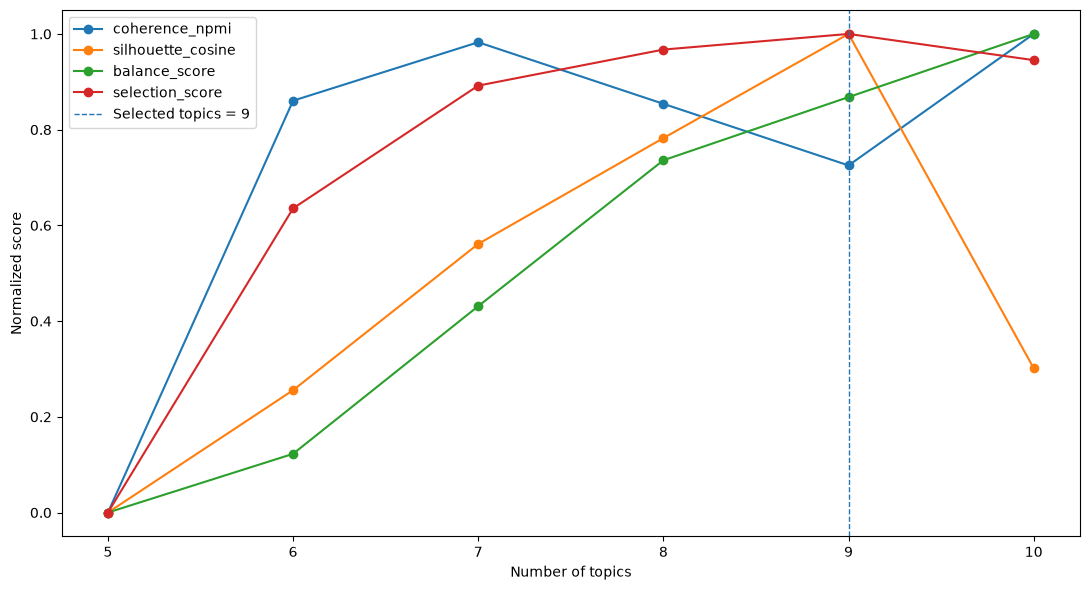

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/global/policy_global_topic_selection_metrics.png


In [12]:
# ==========================================
# Plot global BERTopic topic-number selection metrics
# ==========================================

plot_topic_selection_metrics(
    global_topic_number_search_df,
    GLOBAL_N_TOPICS,
    GLOBAL_IMG_DIR / "policy_global_topic_selection_metrics.png",
)


In [13]:
# ==========================================
# Step 8: Fit the final global BERTopic model
# This uses the selected topic number from the search step.
# ==========================================

global_results = fit_bertopic_kmeans(
    global_topic_data,
    n_topics=GLOBAL_N_TOPICS,
    output_dir=GLOBAL_OUT_DIR,
    output_prefix="policy_global",
    top_n_words=12,
)

global_df = global_results["df"]
global_topic_info = global_results["topic_info"]
global_topic_keywords_df = global_results["topic_keywords"]
global_representative_docs_df = global_results["representative_documents"]

print("Global model fitted.")
print("Global topics:", GLOBAL_N_TOPICS)

print(global_topic_info[["topic", "documents", "share"]])
print(global_topic_keywords_df)


2026-06-30 04:50:46,324 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 04:50:46,325 - BERTopic - Dimensionality - Completed ✓
2026-06-30 04:50:46,326 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 04:50:46,601 - BERTopic - Cluster - Completed ✓
2026-06-30 04:50:46,610 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 04:50:46,647 - BERTopic - Representation - Completed ✓


Global model fitted.
Global topics: 9
   topic  documents     share
0      0        385  0.203919
1      1        330  0.174788
2      2        252  0.133475
3      3        210  0.111229
4      4        198  0.104873
5      5        170  0.090042
6      6        143  0.075742
7      7        128  0.067797
8      8         72  0.038136
   topic                                                                                                                           keywords
0      0                  submission, public, research, sector, people, principle, unesco, recommendation, large, open, investment, company
1      1                       educator, instructional, focus, feedback, literacy, equity, help, learner, guidance, step, leader, equitable
2      2             staff, privacy, academic, integrity, responsible, content, security, personal, bias, assessment, guideline, plagiarism
3      3  usage, outils, cadre, données, pédagogique, numérique, pédagogiques, établissements, utilisa

In [14]:
# ==========================================
# Step 9: Generate global SLM topic phrases
# One SLM call per BERTopic topic only
# ==========================================

def fallback_topic_label(keywords):
    terms = [
        term.strip()
        for term in str(keywords).split(",")
        if term.strip()
    ]

    return " / ".join(terms[:4]) if terms else "Unlabelled topic"


def _representative_snippets_for_topic(representative_docs_df, topic_id, max_docs=4):
    topic_representatives = representative_docs_df[
        representative_docs_df["topic"].eq(topic_id)
    ].copy()

    if "representativeness_score" in topic_representatives.columns:
        topic_representatives = topic_representatives.sort_values(
            "representativeness_score",
            ascending=False,
        )

    representative_snippets = []

    for _, doc_row in topic_representatives.head(max_docs).iterrows():
        snippet = ""

        for text_column in [
            "original_text",
            "heading_context_chunk_text",
            "bertopic_text",
            "processed_text",
        ]:
            if text_column in doc_row.index:
                snippet = str(doc_row.get(text_column, ""))
                break

        snippet = re.sub(r"\s+", " ", snippet).strip()
        representative_snippets.append(snippet[:800])

    return representative_snippets


def generate_slm_topic_phrases(
    topic_info_df,
    topic_keywords_df,
    representative_docs_df,
    output_dir,
    output_prefix,
    corpus_description,
):
    if not SLM_AVAILABLE:
        raise RuntimeError(
            "SLM is not available. Stop here instead of silently using fallback labels. "
            "Check HF_TOKEN, torch, transformers, device memory, and model access. "
            "To skip SLM phrasing, comment out this cell and use keywords directly."
        )

    topic_base_df = topic_info_df[["topic", "documents", "share"]].copy()

    if "keywords" not in topic_base_df.columns:
        topic_base_df = topic_base_df.merge(
            topic_keywords_df[["topic", "keywords"]],
            on="topic",
            how="left",
        )

    topic_phrase_rows = []

    for _, row in topic_base_df.iterrows():
        topic_id = int(row["topic"])
        keywords = str(row.get("keywords", ""))

        representative_snippets = _representative_snippets_for_topic(
            representative_docs_df,
            topic_id,
            max_docs=4,
        )

        label_prompt = f"""
You are labelling one topic from a BERTopic policy corpus about AI, education, youth, digital technology, governance, safety, rights, and public institutions.

Corpus scope:
{corpus_description}

Your task is to produce a specific, human-readable topic phrase.

Top keywords:
{keywords}

Representative policy excerpts:
{chr(10).join("- " + snippet for snippet in representative_snippets[:3])}

Return exactly one valid JSON object with this schema:
{{
  "label": "specific policy topic label, 5 to 12 words",
  "prototype": "one clear sentence describing the policy theme",
  "policy_area": "short policy area",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}}

Label rules:
- Do NOT use generic labels such as "AI Policy", "Digital Policy", "Education Policy", or "Technology Governance".
- The label must mention the concrete policy mechanism, actor, institution, population, or setting.
- Prefer labels like:
  "School AI Governance and Institutional Accountability"
  "Child Data Protection and Online Safety Duties"
  "Teacher Training Requirements for Digital Education"
  "National AI Strategy and Public-Sector Implementation"
- If the topic is about education, say what part: school governance, teacher training, assessment, curriculum, student protection, procurement.
- If the topic is about governance, say what mechanism: regulation, guidance, oversight, risk management, accountability, data protection.
- Use double quotes.
- Use true or false, not True or False.
- Do not include Markdown.
- Do not include explanations outside JSON.
""".strip()

        slm_raw = slm_generate(
            label_prompt,
            max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS,
        )

        slm_json = extract_json_object(slm_raw)

        print(f"\nTopic {topic_id} SLM raw response:")
        print(slm_raw[:500])

        if not slm_json:
            raise RuntimeError(
                f"Could not parse SLM JSON for topic {topic_id}. Raw response:\n{slm_raw}"
            )

        label = str(slm_json.get("label", "")).strip()
        prototype = str(slm_json.get("prototype", "")).strip()

        if not label:
            label = fallback_topic_label(keywords)

        if not prototype:
            prototype = f"Policy topic about {fallback_topic_label(keywords)}."

        topic_phrase_rows.append({
            "topic": topic_id,
            "topic_label": label,
            "topic_prototype": prototype,
            "policy_area": str(slm_json.get("policy_area", "")).strip(),
            "is_coherent": slm_json.get("is_coherent", ""),
            "artifact_topic": slm_json.get("artifact_topic", ""),
            "merge_hint": str(slm_json.get("merge_hint", "")).strip(),
            "keywords": keywords,
            "slm_raw_response": slm_raw,
        })

    topic_phrases_df = pd.DataFrame(topic_phrase_rows)

    topic_phrases_df.to_csv(
        output_dir / f"{output_prefix}_slm_topic_phrases.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return topic_phrases_df


global_topic_phrases_df = generate_slm_topic_phrases(
    global_topic_info,
    global_topic_keywords_df,
    global_representative_docs_df,
    GLOBAL_OUT_DIR,
    "policy_global",
    corpus_description="Global policy documents, including country-specific and international / UNESCO material.",
)

global_topic_label_map = dict(
    zip(global_topic_phrases_df["topic"], global_topic_phrases_df["topic_label"])
)

global_topic_prototype_map = dict(
    zip(global_topic_phrases_df["topic"], global_topic_phrases_df["topic_prototype"])
)

global_df["topic_label"] = global_df["topic"].map(global_topic_label_map)
global_df["topic_prototype"] = global_df["topic"].map(global_topic_prototype_map)

global_topic_phrase_columns = [
    "topic_label",
    "topic_prototype",
    "policy_area",
    "is_coherent",
    "artifact_topic",
    "merge_hint",
]

global_topic_info = global_topic_info.drop(
    columns=[
        col for col in global_topic_phrase_columns
        if col in global_topic_info.columns
    ],
    errors="ignore",
)

global_topic_info = global_topic_info.merge(
    global_topic_phrases_df[
        [
            "topic",
            "topic_label",
            "topic_prototype",
            "policy_area",
            "is_coherent",
            "artifact_topic",
            "merge_hint",
        ]
    ],
    on="topic",
    how="left",
)

global_df.to_csv(
    GLOBAL_OUT_DIR / "policy_global_documents_with_slm_topic_phrases.csv",
    index=False,
    encoding="utf-8-sig",
)

global_topic_info.to_csv(
    GLOBAL_OUT_DIR / "policy_global_topic_info_with_slm_phrases.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Global SLM topic phrasing complete.")

print(
    global_topic_phrases_df[
        [
            "topic",
            "topic_label",
            "topic_prototype",
            "policy_area",
            "is_coherent",
            "artifact_topic",
            "merge_hint",
        ]
    ]
)



Topic 0 SLM raw response:
```json
{
  "label": "AI Curriculum Integration and Oversight",
  "prototype": "Countries worldwide are implementing AI into their educational systems, but there's a growing concern over its integration and oversight.",
  "policy_area": "education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with topics related to AI ethics, privacy, and education reform."
}
```

Topic 1 SLM raw response:
```json
{
  "label": "AI-Assisted Instructional Policies",
  "prototype": "AI-assisted educational systems should have clear guidelines for educator roles, student privacy, and equitable access.",
  "policy_area": "AI-in-education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with existing AI-focused education policies."
}
```

Topic 2 SLM raw response:
```json
{
  "label": "Educational AI Usage Policies",
  "prototype": "Establishing guidelines for the responsible use of AI in schools.",
  "pol

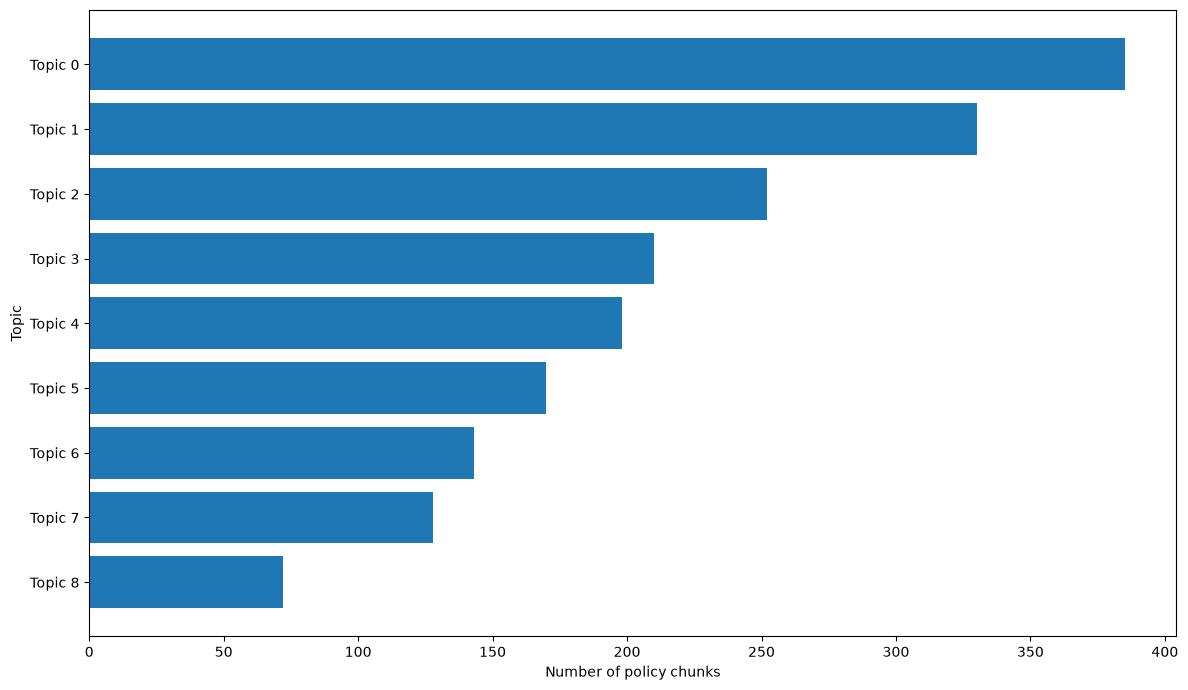

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/global/policy_global_topic_distribution.png


In [15]:
# ==========================================
# Plot global BERTopic topic distribution
# ==========================================

plot_topic_distribution(
    global_topic_info,
    GLOBAL_IMG_DIR / "policy_global_topic_distribution.png",
    topic_keyword_df=global_topic_keywords_df,
    topic_phrase_df=globals().get("global_topic_phrases_df"),
)


In [16]:
# ==========================================
# Step 9: Global topic distribution by country
# This keeps all documents in the global model, but renames unknown as International / UNESCO for reporting.
# ==========================================

# Keep the original country column unchanged for modelling.
# Use country_display only for readable global country-topic outputs.
unknown_country_values = {"unknown", "", "nan", "none"}

global_df["country_display"] = (
    global_df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)

global_df["country_display"] = global_df["country_display"].apply(
    lambda value: "International / UNESCO"
    if value in unknown_country_values
    else value
)

global_topic_country_counts = (
    global_df.groupby(["topic", "country_display"])
    .size()
    .reset_index(name="documents")
)

global_topic_totals = (
    global_df.groupby("topic")
    .size()
    .reset_index(name="topic_total")
)

global_topic_country_distribution = (
    global_topic_country_counts
    .merge(global_topic_totals, on="topic", how="left")
)

global_topic_country_distribution["share_within_topic"] = (
    global_topic_country_distribution["documents"]
    / global_topic_country_distribution["topic_total"]
)

global_topic_country_distribution = (
    global_topic_country_distribution
    .merge(global_topic_keywords_df[["topic", "keywords"]], on="topic", how="left")
)

if "global_topic_phrases_df" in globals():
    global_topic_country_distribution = global_topic_country_distribution.merge(
        global_topic_phrases_df[["topic", "topic_label"]],
        on="topic",
        how="left",
    )

global_topic_country_distribution = (
    global_topic_country_distribution
    .sort_values(["topic", "documents"], ascending=[True, False])
    .reset_index(drop=True)
)

global_country_topic_matrix = pd.crosstab(
    global_df["country_display"],
    global_df["topic"],
    normalize="index",
)

global_topic_country_distribution.to_csv(
    GLOBAL_OUT_DIR / "policy_global_topic_country_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

global_country_topic_matrix.to_csv(
    GLOBAL_OUT_DIR / "policy_global_country_topic_matrix.csv",
    encoding="utf-8-sig",
)

print("Country distribution inside each global topic:")
print(global_topic_country_distribution)

print("\nGlobal-topic share within each country / international group:")
print(global_country_topic_matrix)


Country distribution inside each global topic:
    topic         country_display  documents  topic_total  share_within_topic  \
0       0               australia        144          385            0.374026   
1       0                  france        102          385            0.264935   
2       0                 ireland         82          385            0.212987   
3       0                     usa         40          385            0.103896   
4       0  International / UNESCO         17          385            0.044156   
5       1                     usa        261          330            0.790909   
6       1               australia         53          330            0.160606   
7       1                  france          8          330            0.024242   
8       1                 ireland          8          330            0.024242   
9       2               australia        104          252            0.412698   
10      2                     usa         92          252     

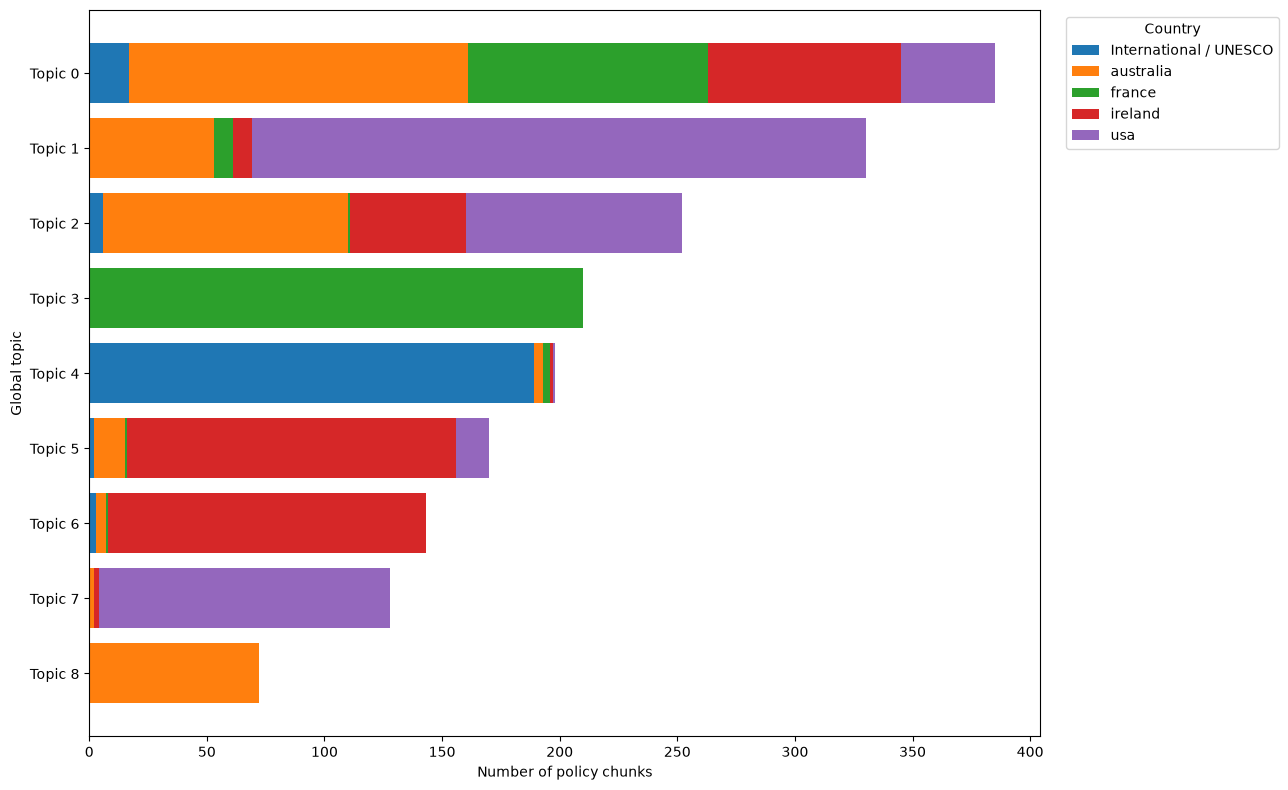

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/global/policy_global_topic_distribution_by_country.png


In [17]:
# ==========================================
# Plot global topic distribution by country
# ==========================================

plot_topic_distribution_by_country(
    global_topic_country_distribution,
    GLOBAL_IMG_DIR / "policy_global_topic_distribution_by_country.png",
    topic_keyword_df=global_topic_keywords_df,
    topic_phrase_df=globals().get("global_topic_phrases_df"),
)


Countries included in per-country discovery:
           chunks
country          
usa           532
ireland       417
australia     396
france        326

Excluded from per-country discovery, but kept in global discovery:
                                 excluded_doc_id
0    policy_ai_competency_framework_for_students
123  policy_ai_competency_framework_for_teachers
Country: australia
Chunks: 396


2026-06-30 04:56:49,032 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 04:56:49,032 - BERTopic - Dimensionality - Completed ✓
2026-06-30 04:56:49,033 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 04:56:49,179 - BERTopic - Cluster - Completed ✓
2026-06-30 04:56:49,183 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 04:56:49,198 - BERTopic - Representation - Completed ✓



Topic 0 SLM raw response:
```json
{
  "label": "AI Integration and Student Learning Oversight",
  "prototype": "Guidance on responsible AI integration in Australian schools.",
  "policy_area": "school governance",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with 'Student Privacy and Academic Integrity' if both topics align closely."
}
```

Topic 1 SLM raw response:
```json
{
  "label": "AI Governance and Child Rights",
  "prototype": "The Australian government has established an AI ethics framework aimed at ensuring the safe and fair use of AI technologies.",
  "policy_area": "AI Governance",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with 'AI Ethics Guidelines for Youth Privacy'"
}
```

Topic 2 SLM raw response:
```json
{
  "label": "Cognitive Offloading and Metacognition in Digital Learning",
  "prototype": "The Australian Network for Quality Digital Education addresses the challenges of AI and harmful 

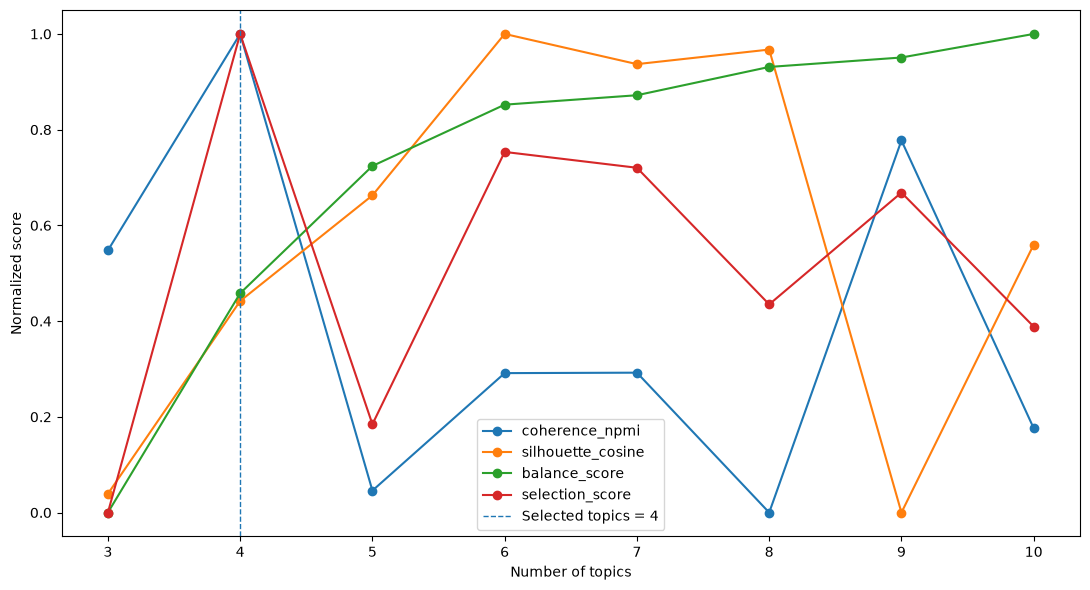

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/australia/policy_australia_topic_selection_metrics.png


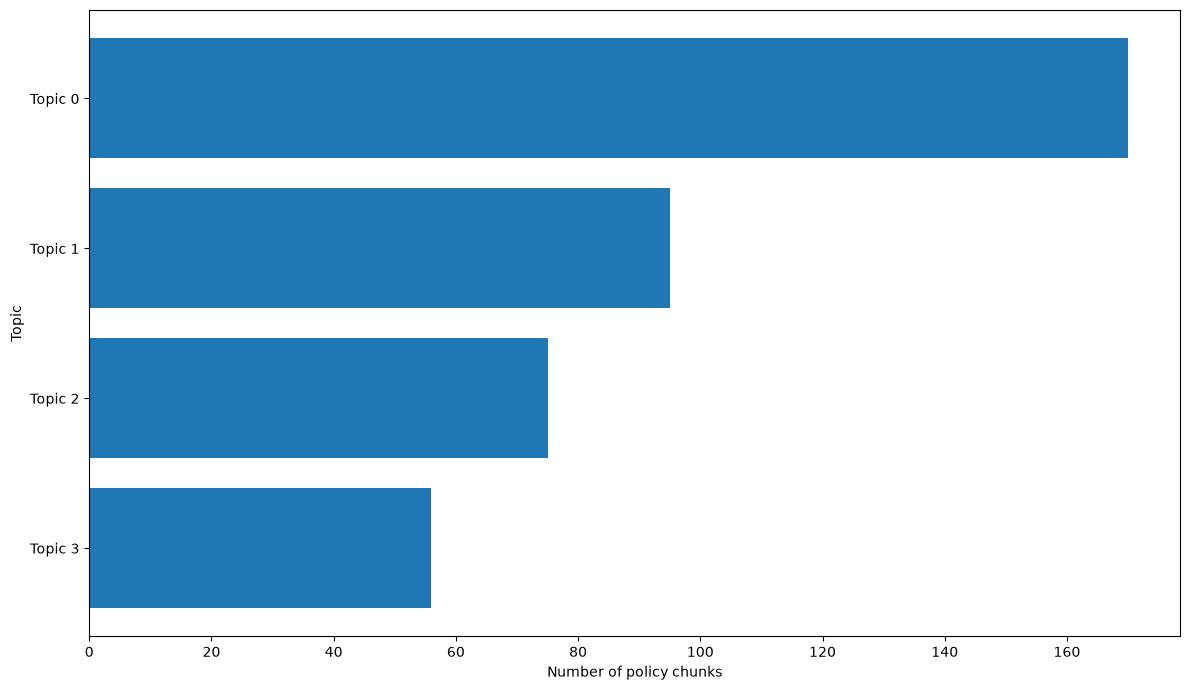

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/australia/policy_australia_topic_distribution.png
Selected topics for australia: 4
   topic  documents                                          Name  \
0      0        170           0_staff_assessment_content_generate   
1      1         95  1_principle_ethical_accountability_framework   
2      2         75        2_cognitive_load_offload_metacognitive   
3      3         56   3_submission_recommendation_inquiry_tension   

                                                                                                                Representation  \
0                  [staff, assessment, content, generate, help, task, personal, academic, teach, privacy, guideline, feedback]   
1  [principle, ethical, accountability, framework, transparency, child, privacy, fairness, wellbeing, guidance, safety, teach]   
2        [cognitive, load, offload, metacognitive, study, critical, learner, performan

2026-06-30 04:59:35,839 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 04:59:35,840 - BERTopic - Dimensionality - Completed ✓
2026-06-30 04:59:35,841 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 04:59:35,985 - BERTopic - Cluster - Completed ✓
2026-06-30 04:59:35,988 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 04:59:36,005 - BERTopic - Representation - Completed ✓



Topic 0 SLM raw response:
```json
{
  "label": "National AI Strategy Implementation in Education Institutions",
  "prototype": "The French government has implemented a national strategy on artificial intelligence in education, focusing on deploying AI technologies across various levels of educational institutions.",
  "policy_area": "Education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with existing topics related to AI in education, national strategies, and institutional implementation."


Topic 1 SLM raw response:
```json
{
  "label": "AI in French School Curriculum and Teacher Training",
  "prototype": "French schools are implementing AI tools to enhance learning experiences while ensuring ethical considerations.",
  "policy_area": "school curriculum and teacher training",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with 'AI in French Education and Youth Development'"
}
```

Topic 2 SLM raw response:
```json
{
  "label": 

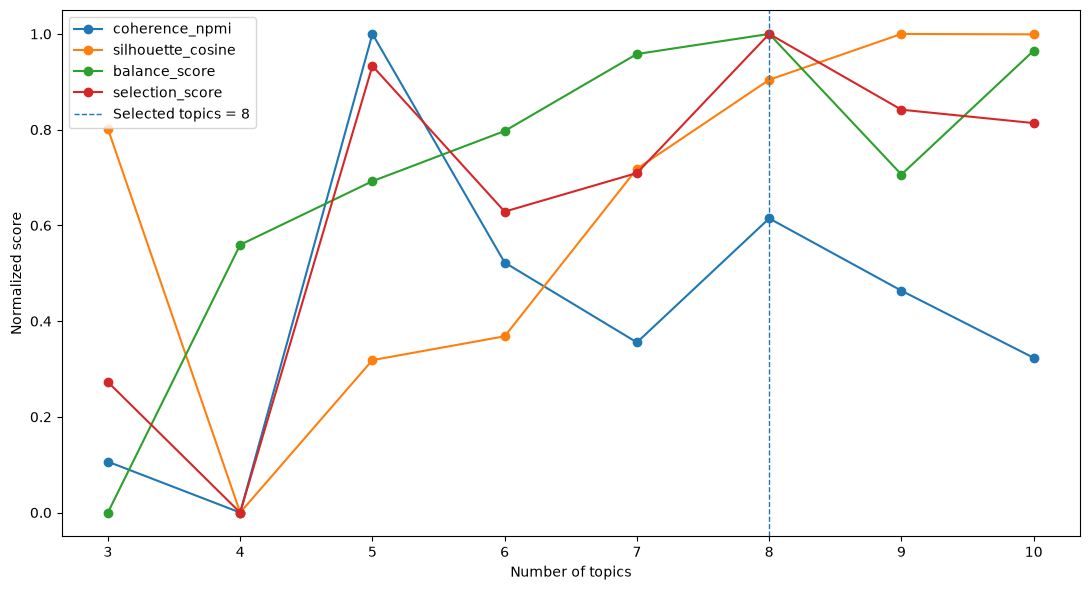

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/france/policy_france_topic_selection_metrics.png


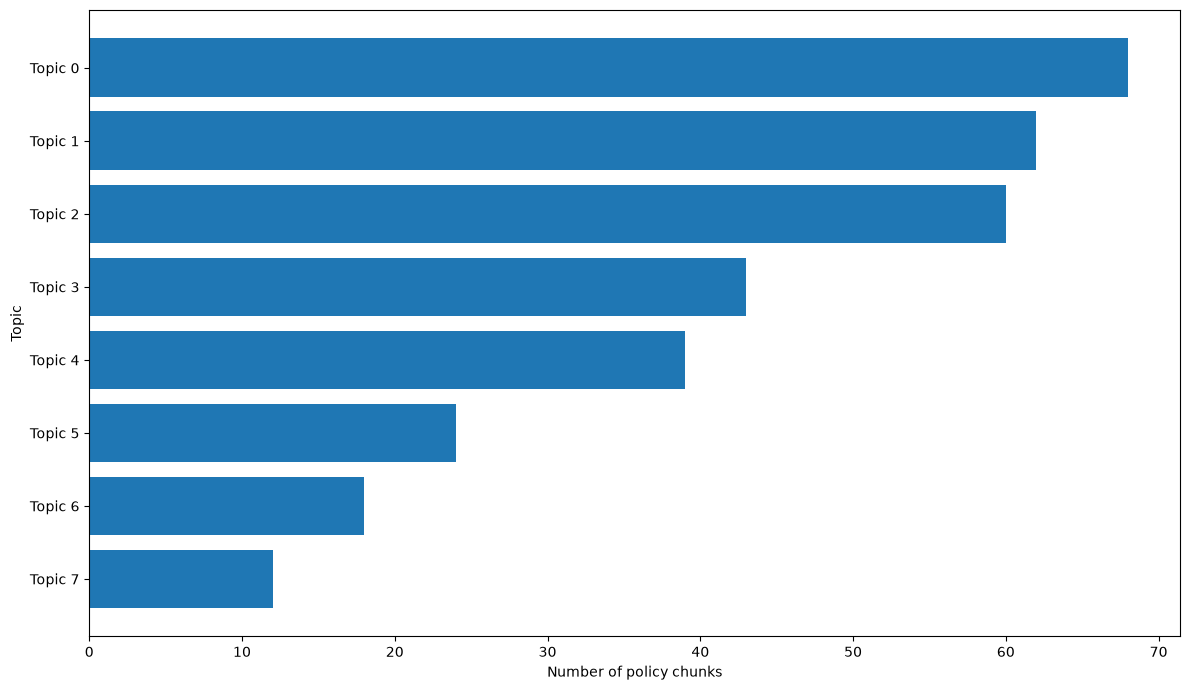

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/france/policy_france_topic_distribution.png
Selected topics for france: 8
   topic  documents                                        Name  \
0      0         68  0_déploiement_acteurs_établissements_place   
1      1         62        1_outils_données_utilisation_risques   
2      2         60         2_recherche_comprendre_prompt_venir   
3      3         43            3_language_teach_source_response   
4      4         39      4_investment_research_economic_company   
5      5         24                5_court_legal_patent_protect   
6      6         18   6_répondants_questionnaire_extrait_manque   
7      7         12      7_adjoint_directeur_académique_délégué   

                                                                                                                   Representation  \
0              [déploiement, acteurs, établissements, place, mise, sein, académiques, entre, n

2026-06-30 05:05:10,184 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 05:05:10,185 - BERTopic - Dimensionality - Completed ✓
2026-06-30 05:05:10,186 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 05:05:10,323 - BERTopic - Cluster - Completed ✓
2026-06-30 05:05:10,325 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 05:05:10,339 - BERTopic - Representation - Completed ✓



Topic 0 SLM raw response:
```json
{
  "label": "Ireland AI Governance and Public Oversight",
  "prototype": "The Irish government should establish a comprehensive AI governance framework to oversee ethical AI development and deployment.",
  "policy_area": "AI Governance",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with 'Ireland AI Ethics Framework'"
}
```

Topic 1 SLM raw response:
```json
{
  "label": "Digital Learning Framework Implementation and Teacher Professional Development",
  "prototype": "This strategy aims to implement the Digital Learning Framework and enhance teacher professional development in Ireland.",
  "policy_area": "education",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with existing policies focusing on digital learning frameworks and teacher professional development."
}
```

Topic 2 SLM raw response:
```json
{
  "label": "Teaching Staff AI Utilization and Academic Responsibility",
  "prototype

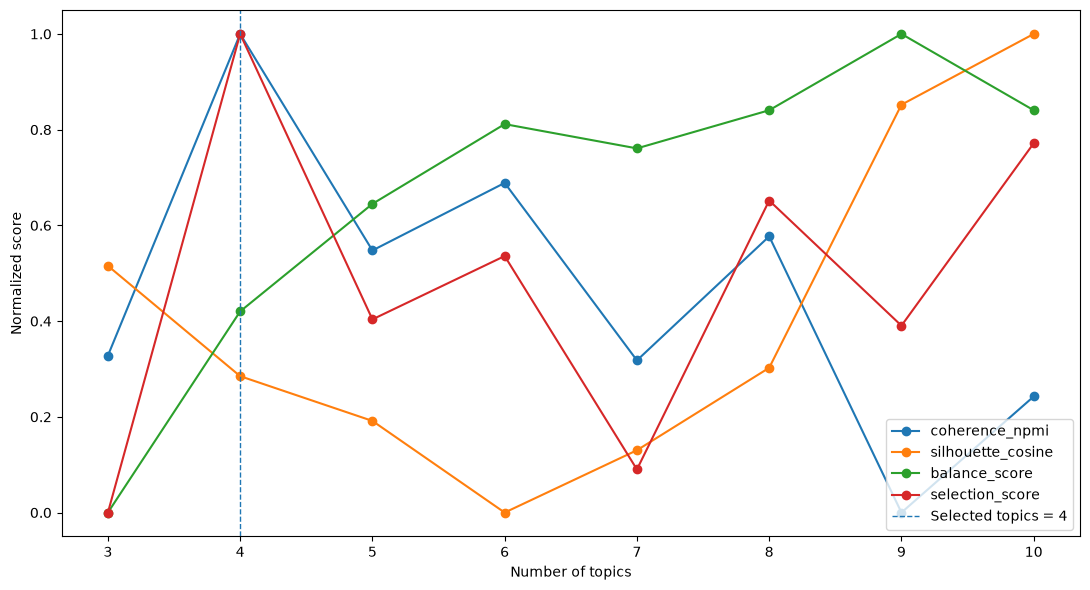

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/ireland/policy_ireland_topic_selection_metrics.png


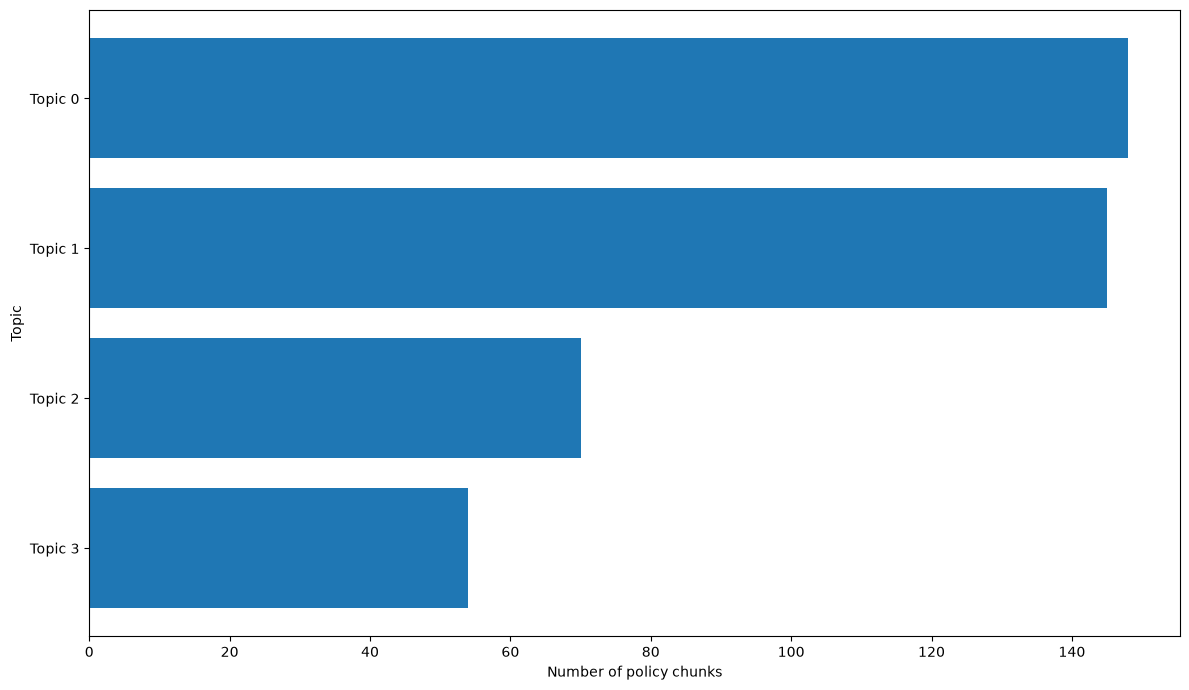

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/ireland/policy_ireland_topic_distribution.png
Selected topics for ireland: 4
   topic  documents                                 Name  \
0      0        148  0_people_public_regulation_research   
1      1        145      1_learner_teach_leader_progress   
2      2         70      2_staff_content_source_generate   
3      3         54     3_sexual_abuse_convention_europe   

                                                                                                                   Representation  \
0          [people, public, regulation, research, recommender, safety, risk, recommendation, company, disability, parent, social]   
1  [learner, teach, leader, progress, skill, professional, curriculum, assessment, framework, competence, infrastructure, pillar]   
2                         [staff, content, source, generate, bias, academic, accuracy, assessment, response, task, tutor, output

2026-06-30 05:07:58,054 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 05:07:58,055 - BERTopic - Dimensionality - Completed ✓
2026-06-30 05:07:58,056 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 05:07:58,204 - BERTopic - Cluster - Completed ✓
2026-06-30 05:07:58,206 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 05:07:58,225 - BERTopic - Representation - Completed ✓



Topic 0 SLM raw response:
```json
{
  "label": "AI-Powered Learning and Teacher Support",
  "prototype": "The integration of AI technologies in educational settings enhances learning outcomes while providing personalized support to educators.",
  "policy_area": "EdTech and Teacher Training",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}
```

Topic 1 SLM raw response:
```json
{
  "label": "AI-Policy Oversight and Child Privacy",
  "prototype": "The US government has implemented policies to ensure the ethical use of AI in educational settings.",
  "policy_area": "school governance",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Consider merging with 'AI-Policy Oversight and Student Rights' for more comprehensive coverage."
}
```

Topic 2 SLM raw response:
```json
{
  "label": "District AI Use Guidelines and Oversight",
  "prototype": "District-level guidelines and oversight frameworks for integrating artificial intelligence into K-12 educati

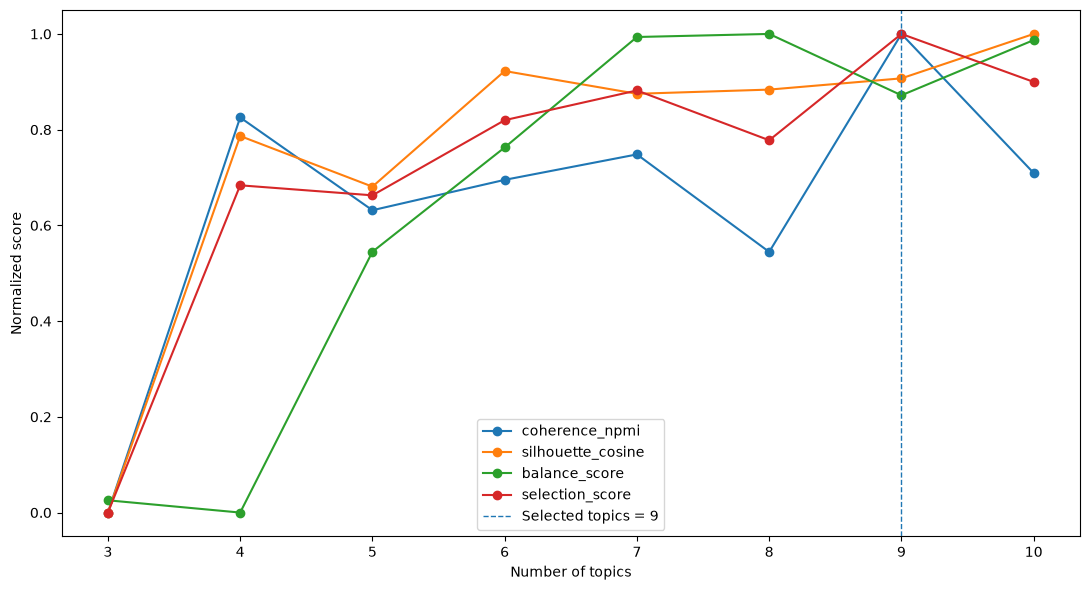

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/usa/policy_usa_topic_selection_metrics.png


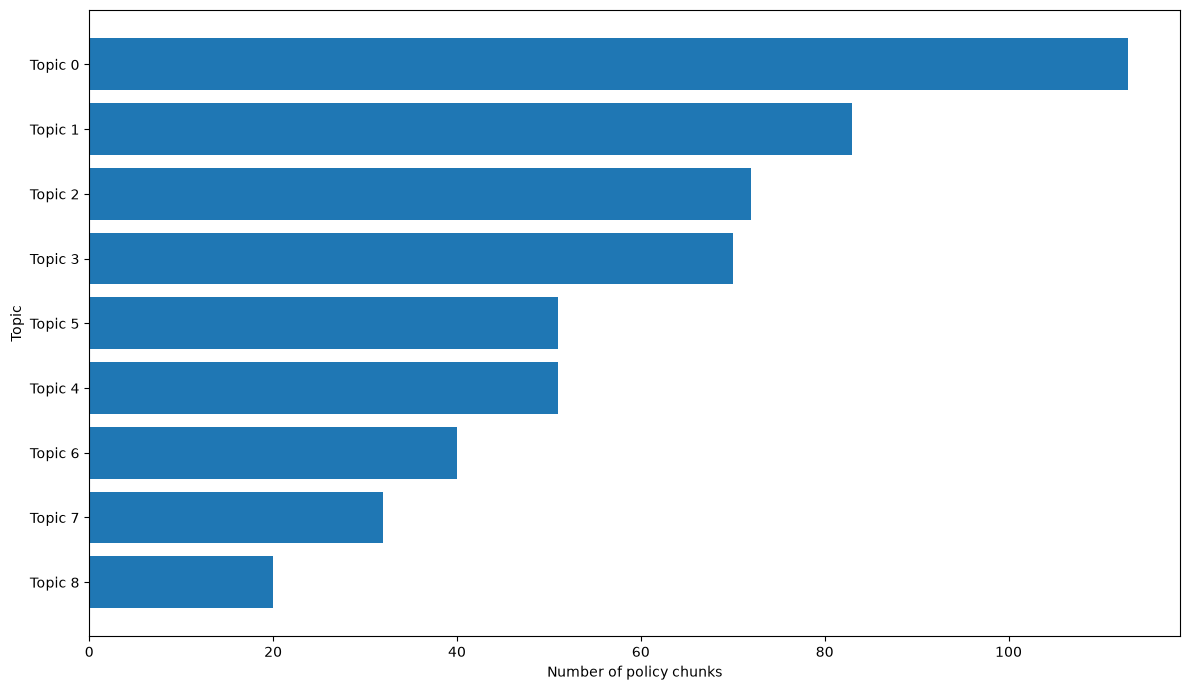

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/usa/policy_usa_topic_distribution.png
Selected topics for usa: 9
   topic  documents                                          Name  \
0      0        113       0_research_formative_learner_assessment   
1      1         83              1_medium_synthetic_child_privacy   
2      2         72        2_literacy_guidance_framework_educator   
3      3         70                   3_english_write_think_thing   
4      4         51                 4_staff_trust_pupils_academic   
5      5         51        5_achievement_disadvantage_effect_math   
6      6         40                   6_step_action_focus_ethical   
7      7         32  7_legal_compliance_procurement_accessibility   
8      8         20                  8_guidebook_best_try_arrival   

                                                                                                                      Representation  \
0            

In [18]:
# ==========================================
# Step 10: Per-country topic discovery
# This fits one separate topic model for each real country.
# International / UNESCO documents are excluded only here.
# ==========================================

COUNTRY_OUT_DIR = OUT_DIR / "per_country"
COUNTRY_OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_COUNTRY_DOCUMENTS = 80
RUN_PER_COUNTRY_SLM_PHRASES = True

# Keep unknown / UNESCO documents in the global model,
# but exclude them from country-specific discovery.
excluded_country_values = {"unknown", "", "nan", "none"}

per_country_df = df[
    ~df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(excluded_country_values)
].copy()

excluded_per_country_df = df[
    df["country"]
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(excluded_country_values)
].copy()

print("Countries included in per-country discovery:")
print(per_country_df["country"].value_counts().to_frame("chunks"))

print("\nExcluded from per-country discovery, but kept in global discovery:")
print(
    excluded_per_country_df["doc_id"]
    .drop_duplicates()
    .to_frame("excluded_doc_id")
)

country_model_summary_rows = []
country_results = {}

for country in sorted(per_country_df["country"].dropna().unique()):
    country_df = per_country_df[per_country_df["country"].eq(country)].copy()

    if len(country_df) < MIN_COUNTRY_DOCUMENTS:
        print(f"Skipping {country}: only {len(country_df)} chunks.")
        continue

    print("=" * 80)
    print(f"Country: {country}")
    print(f"Chunks: {len(country_df)}")

    safe_country = re.sub(r"[^a-zA-Z0-9_]+", "_", country).strip("_")

    country_output_dir = COUNTRY_OUT_DIR / safe_country
    country_output_dir.mkdir(parents=True, exist_ok=True)

    country_image_dir = COUNTRY_IMG_DIR / safe_country
    country_image_dir.mkdir(parents=True, exist_ok=True)

    country_topic_data = prepare_topic_inputs(
        country_df,
        min_df=3,
        max_df=0.35,
        max_features=2000,
        svd_components=80,
    )

    country_search_df, country_n_topics = search_best_topic_number(
        country_topic_data,
        min_topics=3,
        max_topics=10,
        top_n_words=12,
        dominance_threshold=0.50,
    )

    country_search_df.to_csv(
        country_output_dir / f"policy_{safe_country}_topic_number_search.csv",
        index=False,
        encoding="utf-8-sig",
    )

    country_result = fit_bertopic_kmeans(
        country_topic_data,
        n_topics=country_n_topics,
        output_dir=country_output_dir,
        output_prefix=f"policy_{safe_country}",
        top_n_words=12,
    )

    country_topic_info = country_result["topic_info"]
    country_topic_keywords_df = country_result["topic_keywords"]
    country_representative_docs_df = country_result["representative_documents"]
    country_final_df = country_result["df"]

    if RUN_PER_COUNTRY_SLM_PHRASES:
        country_topic_phrases_df = generate_slm_topic_phrases(
            country_topic_info,
            country_topic_keywords_df,
            country_representative_docs_df,
            country_output_dir,
            f"policy_{safe_country}",
            corpus_description=f"Policy documents for {country}.",
        )

        country_topic_label_map = dict(
            zip(country_topic_phrases_df["topic"], country_topic_phrases_df["topic_label"])
        )

        country_topic_prototype_map = dict(
            zip(country_topic_phrases_df["topic"], country_topic_phrases_df["topic_prototype"])
        )

        country_final_df["topic_label"] = country_final_df["topic"].map(country_topic_label_map)
        country_final_df["topic_prototype"] = country_final_df["topic"].map(country_topic_prototype_map)

        country_topic_phrase_columns = [
            "topic_label",
            "topic_prototype",
            "policy_area",
            "is_coherent",
            "artifact_topic",
            "merge_hint",
        ]

        country_topic_info = country_topic_info.drop(
            columns=[
                col for col in country_topic_phrase_columns
                if col in country_topic_info.columns
            ],
            errors="ignore",
        )

        country_topic_info = country_topic_info.merge(
            country_topic_phrases_df[
                [
                    "topic",
                    "topic_label",
                    "topic_prototype",
                    "policy_area",
                    "is_coherent",
                    "artifact_topic",
                    "merge_hint",
                ]
            ],
            on="topic",
            how="left",
        )

        country_final_df.to_csv(
            country_output_dir / f"policy_{safe_country}_documents_with_slm_topic_phrases.csv",
            index=False,
            encoding="utf-8-sig",
        )

        country_topic_info.to_csv(
            country_output_dir / f"policy_{safe_country}_topic_info_with_slm_phrases.csv",
            index=False,
            encoding="utf-8-sig",
        )

    else:
        country_topic_phrases_df = None

    plot_topic_selection_metrics(
        country_search_df,
        country_n_topics,
        country_image_dir / f"policy_{safe_country}_topic_selection_metrics.png",
    )

    plot_topic_distribution(
        country_topic_info,
        country_image_dir / f"policy_{safe_country}_topic_distribution.png",
        topic_keyword_df=country_topic_keywords_df,
        topic_phrase_df=country_topic_phrases_df,
    )

    country_result["topic_info_with_phrases"] = country_topic_info
    country_result["topic_phrases"] = country_topic_phrases_df

    country_results[country] = country_result

    largest_topic_share = (
        country_topic_info["share"].max()
        if len(country_topic_info) > 0
        else np.nan
    )

    country_model_summary_rows.append({
        "country": country,
        "documents_used": len(country_final_df),
        "selected_topics": country_n_topics,
        "largest_topic_share": largest_topic_share,
        "output_folder": str(country_output_dir),
        "image_folder": str(country_image_dir),
    })

    print(f"Selected topics for {country}: {country_n_topics}")
    print(country_topic_info)


country_model_summary_df = pd.DataFrame(country_model_summary_rows)

country_model_summary_df.to_csv(
    COUNTRY_OUT_DIR / "policy_country_model_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Per-country model summary:")
print(country_model_summary_df)


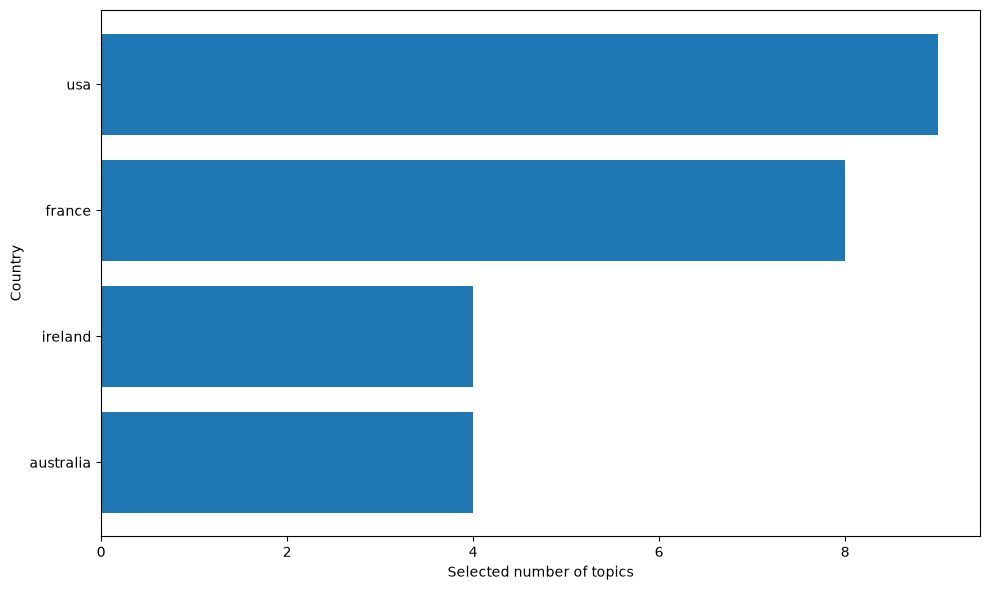

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/bertopic/policy/img/per_country/policy_per_country_selected_topic_counts.png


In [19]:
# ==========================================
# Plot per-country selected topic counts
# ==========================================

plot_country_selected_topic_counts(
    country_model_summary_df,
    COUNTRY_IMG_DIR / "policy_per_country_selected_topic_counts.png",
)


In [20]:
# ==========================================
# Review SLM topic phrases
# SLM-generated phrases replace the old manual-label template.
# ==========================================

if "global_topic_phrases_df" in globals():
    print("Global SLM topic phrases:")
    print(
        global_topic_phrases_df[
            [
                "topic",
                "topic_label",
                "topic_prototype",
                "policy_area",
                "is_coherent",
                "artifact_topic",
                "merge_hint",
            ]
        ]
    )

    print("Saved:")
    print(GLOBAL_OUT_DIR / "policy_global_slm_topic_phrases.csv")
    print(GLOBAL_OUT_DIR / "policy_global_topic_info_with_slm_phrases.csv")
    print(GLOBAL_OUT_DIR / "policy_global_documents_with_slm_topic_phrases.csv")

else:
    print("global_topic_phrases_df not found. Run the SLM topic phrasing cell first.")


Global SLM topic phrases:
   topic                                          topic_label  \
0      0              AI Curriculum Integration and Oversight   
1      1                   AI-Assisted Instructional Policies   
2      2                        Educational AI Usage Policies   
3      3         AI in School Curriculum and Teacher Training   
4      4            Competency-Based Education and Assessment   
5      5             AI Child Protection and Rights Oversight   
6      6               Digital Learning Progression Framework   
7      7              AI in Education and Student Achievement   
8      8  AI Offloading and Metacognitive Skills in Education   

                                                                                                                                       topic_prototype  \
0            Countries worldwide are implementing AI into their educational systems, but there's a growing concern over its integration and oversight.   
1              